In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("❌ T4 GPU is not available")

device = torch.device("cuda")

print("GPU:", torch.cuda.get_device_name(0))
print("CUDA:", torch.version.cuda)

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4
CUDA: 13.0


In [2]:
!git clone https://github.com/savannahfung/animal-image-classification.git

import os

repo_path = "/content/animal-image-classification"

print("Repository exists:", os.path.exists(repo_path))
print("\nRepository contents:")

for item in os.listdir(repo_path):
    print("📁", item)

fatal: destination path 'animal-image-classification' already exists and is not an empty directory.
Repository exists: True

Repository contents:
📁 .git
📁 README.md
📁 src
📁 notebooks
📁 dataset
📁 models
📁 .gitignore
📁 requirements.txt
📁 results


In [3]:
import os

dataset_path = "/content/animal-image-classification/dataset"

print("Dataset path:", dataset_path)
print("Exists:", os.path.exists(dataset_path))

print("\nDataset contents:")

for item in os.listdir(dataset_path):
    print("📁", item)

Dataset path: /content/animal-image-classification/dataset
Exists: True

Dataset contents:
📁 animals
📁 translation.json


In [4]:
import os

dataset_path = "/content/animal-image-classification/dataset"

print("Searching dataset structure...\n")

for root, dirs, files in os.walk(dataset_path):

    level = root.replace(dataset_path, "").count(os.sep)

    if level <= 2:
        print("📁", root)

        for f in files[:5]:
            print("   📄", f)

Searching dataset structure...

📁 /content/animal-image-classification/dataset
   📄 translation.json
📁 /content/animal-image-classification/dataset/animals
   📄 .DS_Store
📁 /content/animal-image-classification/dataset/animals/aptenodytes-forsteri
   📄 aptenodytes-forsteri_90_8ec13cf5.jpg
   📄 aptenodytes-forsteri_0_06fd89f2.jpg
   📄 aptenodytes-forsteri_70_813268ce.jpg
   📄 aptenodytes-forsteri_55_5dd44075.jpg
   📄 aptenodytes-forsteri_27_b1a22187.jpg
📁 /content/animal-image-classification/dataset/animals/passerina-ciris
   📄 passerina-ciris_79_5ad2aa27.jpg
   📄 passerina-ciris_96_6ec67879.jpg
   📄 passerina-ciris_48_ab442bad.jpg
   📄 passerina-ciris_98_6346f67e.jpg
   📄 passerina-ciris_21_501403e5.jpg
📁 /content/animal-image-classification/dataset/animals/poecile-atricapillus
   📄 poecile-atricapillus_23_41381417.jpg
   📄 poecile-atricapillus_73_2e534632.jpg
   📄 poecile-atricapillus_38_5377e42a.jpg
   📄 poecile-atricapillus_89_a41bbcfd.jpg
   📄 poecile-atricapillus_37_e8fdf58f.jpg
📁 

In [5]:
# CELL 5 — Find the actual image dataset folders

import os

REPO_PATH = "/content/animal-image-classification"

print("Searching for image folders...\n")

# Search while ignoring .git
for root, dirs, files in os.walk(REPO_PATH):
    dirs[:] = [d for d in dirs if d != ".git"]

    # Show directories that contain image files
    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    if image_files:
        print("📁", root)
        print("   Images:", len(image_files))

Searching for image folders...

📁 /content/animal-image-classification/dataset/animals/aptenodytes-forsteri
   Images: 30
📁 /content/animal-image-classification/dataset/animals/passerina-ciris
   Images: 50
📁 /content/animal-image-classification/dataset/animals/poecile-atricapillus
   Images: 50
📁 /content/animal-image-classification/dataset/animals/smilodon-populator
   Images: 30
📁 /content/animal-image-classification/dataset/animals/dendrobatidae
   Images: 32
📁 /content/animal-image-classification/dataset/animals/panthera-leo
   Images: 47
📁 /content/animal-image-classification/dataset/animals/spinosaurus-aegyptiacus
   Images: 31
📁 /content/animal-image-classification/dataset/animals/crocodylus-niloticus
   Images: 31
📁 /content/animal-image-classification/dataset/animals/phascolarctos-cinereus
   Images: 50
📁 /content/animal-image-classification/dataset/animals/gallus-gallus-domesticus
   Images: 31
📁 /content/animal-image-classification/dataset/animals/panthera-onca
   Images: 4

In [6]:
# Cell 6 - Set the actual dataset path

SOURCE_DIR = "/content/animal-image-classification/dataset/animals"

print("Dataset path:")
print(SOURCE_DIR)

print("\nDataset exists:", os.path.exists(SOURCE_DIR))

classes = [
    d for d in os.listdir(SOURCE_DIR)
    if os.path.isdir(os.path.join(SOURCE_DIR, d))
    and not d.startswith(".")
]

print("\nNumber of animal classes:", len(classes))
print("\nFirst 20 classes:")
print(classes[:20])

Dataset path:
/content/animal-image-classification/dataset/animals

Dataset exists: True

Number of animal classes: 151

First 20 classes:
['aptenodytes-forsteri', 'passerina-ciris', 'poecile-atricapillus', 'smilodon-populator', 'dendrobatidae', 'panthera-leo', 'spinosaurus-aegyptiacus', 'crocodylus-niloticus', 'phascolarctos-cinereus', 'gallus-gallus-domesticus', 'panthera-onca', 'bos-taurus', 'mammuthus-primigeniu', 'ceratitis-capitata', 'mellisuga-helenae', 'codium-fragile', 'agkistrodon-contortrix', 'bradypus-variegatus', 'aethia-cristatella', 'crotalus-atrox']


In [7]:
# Cell 7 - Image preprocessing

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Image transforms created!")

✅ Image transforms created!


In [8]:
# Cell 8 - Create ImageFolder datasets

from torchvision import datasets

# Use the actual dataset as the source
train_dataset = datasets.ImageFolder(
    SOURCE_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    SOURCE_DIR,
    transform=val_transform
)

print("✅ Dataset loaded successfully!")
print("Number of classes:", len(train_dataset.classes))
print("Number of images:", len(train_dataset))

print("\nFirst 10 classes:")
print(train_dataset.classes[:10])

✅ Dataset loaded successfully!
Number of classes: 151
Number of images: 6270

First 10 classes:
['acinonyx-jubatus', 'aethia-cristatella', 'agalychnis-callidryas', 'agkistrodon-contortrix', 'ailuropoda-melanoleuca', 'ailurus-fulgens', 'alces-alces', 'anas-platyrhynchos', 'ankylosaurus-magniventris', 'apis-mellifera']


In [9]:
# Cell 9 - Properly split dataset into Train / Validation / Test

import torch
from torch.utils.data import random_split, Subset
from torchvision import datasets

# Create one base dataset to get all images and class labels
base_dataset = datasets.ImageFolder(
    SOURCE_DIR,
    transform=None
)

# Total images
total_size = len(base_dataset)

# 80% Train, 10% Validation, 10% Test
train_size = int(0.80 * total_size)
val_size = int(0.10 * total_size)
test_size = total_size - train_size - val_size

# Fixed random seed so the split stays the same
generator = torch.Generator().manual_seed(42)

train_base, val_base, test_base = random_split(
    base_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

# Create datasets with the correct transforms
train_full = datasets.ImageFolder(
    SOURCE_DIR,
    transform=train_transform
)

val_full = datasets.ImageFolder(
    SOURCE_DIR,
    transform=val_transform
)

test_full = datasets.ImageFolder(
    SOURCE_DIR,
    transform=val_transform
)

# Use exactly the same indices for each split
train_dataset = Subset(train_full, train_base.indices)
val_dataset = Subset(val_full, val_base.indices)
test_dataset = Subset(test_full, test_base.indices)

print("✅ Dataset split successfully!")
print()
print("Total images:", total_size)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Number of classes:", len(base_dataset.classes))

✅ Dataset split successfully!

Total images: 6270
Training images: 5016
Validation images: 627
Test images: 627
Number of classes: 151


In [10]:
# Cell 10 - DataLoaders

from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ DataLoaders created!")
print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

✅ DataLoaders created!
Batch size: 64
Training batches: 79
Validation batches: 10
Test batches: 10


In [11]:
# CELL 11 — Improved ResNet50 Fine-Tuning

import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

num_classes = len(base_dataset.classes)

# Load pretrained ResNet50
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

# ------------------------------------------------
# Freeze everything first
# ------------------------------------------------
for param in model.parameters():
    param.requires_grad = False

# ------------------------------------------------
# Unfreeze Layer 4 for fine-tuning
# ------------------------------------------------
for param in model.layer4.parameters():
    param.requires_grad = True

# ------------------------------------------------
# Replace classification head
# ------------------------------------------------
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.fc.in_features, num_classes)
)

# Move to GPU
model = model.to(device)

# Count trainable parameters
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel() for p in model.parameters()
)

print("\n✅ Improved ResNet50 ready!")
print("Number of classes:", num_classes)
print("Trainable parameters:", f"{trainable_params:,}")
print("Total parameters:", f"{total_params:,}")
print("Model device:", next(model.parameters()).device)

Device: cuda
GPU: Tesla T4

✅ Improved ResNet50 ready!
Number of classes: 151
Trainable parameters: 15,274,135
Total parameters: 23,817,431
Model device: cuda:0


In [12]:
# CELL 12 — Optimizer and Learning Rate Scheduler

import torch.optim as optim

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# Different learning rates:
# - Layer 4: small LR because it is pretrained
# - FC: larger LR because it is newly initialized

optimizer = optim.AdamW(
    [
        {
            "params": model.layer4.parameters(),
            "lr": 1e-4
        },
        {
            "params": model.fc.parameters(),
            "lr": 1e-3
        }
    ],
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.3,
    patience=2
)

print("✅ Optimizer:", optimizer)
print("✅ Scheduler:", scheduler)
print("Learning rate - Layer4: 0.0001")
print("Learning rate - FC: 0.001")
print("Label smoothing: 0.1")

✅ Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
✅ Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x7a2a971d63c0>
Learning rate - Layer4: 0.0001
Learning rate - FC: 0.001
Label smoothing: 0.1


In [13]:
# CELL 13 — Mixed Precision

scaler = torch.amp.GradScaler("cuda")

print("✅ Mixed precision enabled")
print("GPU:", torch.cuda.get_device_name(0))

✅ Mixed precision enabled
GPU: Tesla T4


In [14]:
# CELL 14 — Training Function

def train_one_epoch():

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):

            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        # Prevent extremely large gradients
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("✅ Improved training function created!")

✅ Improved training function created!


In [15]:
# Cell 15 - Validation function

def validate():

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            # Move data to T4
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Mixed precision
            with torch.amp.autocast("cuda"):

                outputs = model(images)
                loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_accuracy = correct / total

    return val_loss, val_accuracy


print("✅ Validation function created!")

✅ Validation function created!


In [16]:
# CELL 16 — Improved ResNet50 Training

NUM_EPOCHS = 15

best_accuracy = 0.0

best_model_path = "/content/best_animal_classifier.pth"

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

print("=" * 70)
print("🚀 STARTING IMPROVED RESNET50 TRAINING")
print("=" * 70)

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 70)

    # -------------------------
    # Training
    # -------------------------

    train_loss, train_accuracy = train_one_epoch()

    # -------------------------
    # Validation
    # -------------------------

    val_loss, val_accuracy = validate()

    # -------------------------
    # Learning rate scheduler
    # -------------------------

    scheduler.step(val_accuracy)

    # -------------------------
    # Save history
    # -------------------------

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # -------------------------
    # Current learning rates
    # -------------------------

    current_lrs = [
        group["lr"]
        for group in optimizer.param_groups
    ]

    # -------------------------
    # Display results
    # -------------------------

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy * 100:.2f}%"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy * 100:.2f}%"
    )

    print(
        f"LR Layer4: {current_lrs[0]:.7f} | "
        f"LR FC: {current_lrs[1]:.7f}"
    )

    # -------------------------
    # Save best model
    # -------------------------

    if val_accuracy > best_accuracy:

        best_accuracy = val_accuracy

        torch.save({
            "model_state_dict": model.state_dict(),
            "classes": base_dataset.classes,
            "num_classes": num_classes,
            "val_accuracy": val_accuracy
        }, best_model_path)

        print("💾 ⭐ BEST MODEL SAVED!")

print("\n" + "=" * 70)
print("🎉 IMPROVED TRAINING COMPLETE")
print("=" * 70)

print(
    f"Best validation accuracy: "
    f"{best_accuracy * 100:.2f}%"
)

print("\nModel saved at:")
print(best_model_path)

🚀 STARTING IMPROVED RESNET50 TRAINING

Epoch 1/15
----------------------------------------------------------------------
Train Loss: 3.7197 | Train Accuracy: 30.54%
Val Loss:   1.7609 | Val Accuracy: 76.56%
LR Layer4: 0.0001000 | LR FC: 0.0010000
💾 ⭐ BEST MODEL SAVED!

Epoch 2/15
----------------------------------------------------------------------
Train Loss: 1.9313 | Train Accuracy: 72.03%
Val Loss:   1.3707 | Val Accuracy: 87.40%
LR Layer4: 0.0001000 | LR FC: 0.0010000
💾 ⭐ BEST MODEL SAVED!

Epoch 3/15
----------------------------------------------------------------------
Train Loss: 1.6450 | Train Accuracy: 79.86%
Val Loss:   1.2681 | Val Accuracy: 89.79%
LR Layer4: 0.0001000 | LR FC: 0.0010000
💾 ⭐ BEST MODEL SAVED!

Epoch 4/15
----------------------------------------------------------------------
Train Loss: 1.5307 | Train Accuracy: 83.37%
Val Loss:   1.2208 | Val Accuracy: 92.19%
LR Layer4: 0.0001000 | LR FC: 0.0010000
💾 ⭐ BEST MODEL SAVED!

Epoch 5/15
--------------------------

In [17]:
# CELL 17 — Final Test Evaluation

checkpoint = torch.load(
    best_model_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast("cuda"):

            outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

test_accuracy = correct / total

print("=" * 70)
print("🧪 FINAL TEST RESULT")
print("=" * 70)

print("Test images:", total)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Best Validation Accuracy: "
    f"{best_accuracy * 100:.2f}%"
)

print("=" * 70)

🧪 FINAL TEST RESULT
Test images: 627
Test Accuracy: 92.19%
Best Validation Accuracy: 93.30%


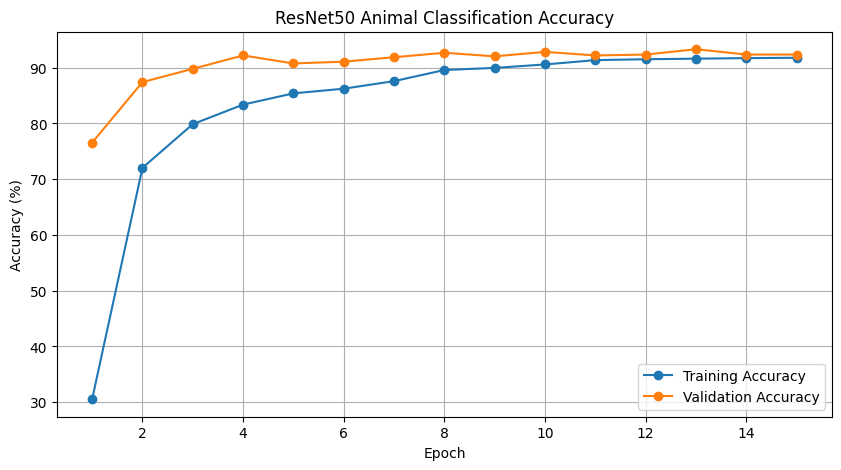

In [18]:
# Cell 18 - Training and Validation Accuracy

import matplotlib.pyplot as plt

epochs = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    [x * 100 for x in train_accuracies],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    [x * 100 for x in val_accuracies],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet50 Animal Classification Accuracy")
plt.legend()
plt.grid(True)

plt.show()

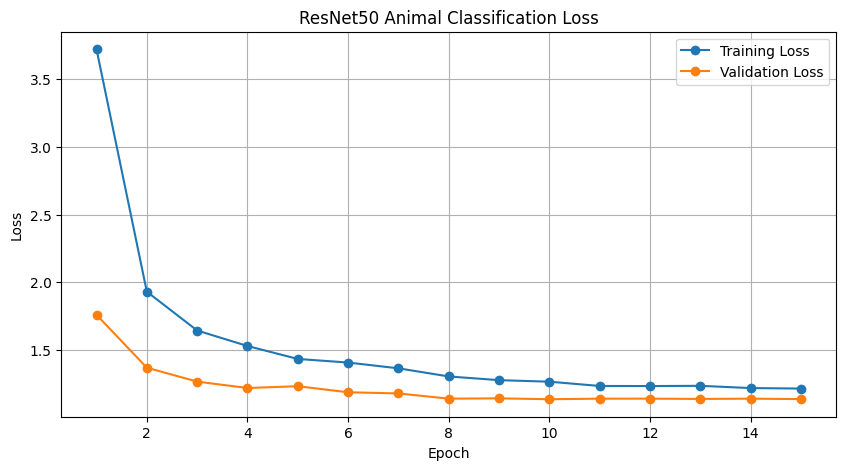

In [19]:
# Cell 19 - Training and Validation Loss

plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Animal Classification Loss")
plt.legend()
plt.grid(True)

plt.show()

🐾 ANIMAL IMAGE PREDICTION
Actual animal:    okapia-johnstoni
Predicted animal: okapia-johnstoni
Confidence:       95.30%


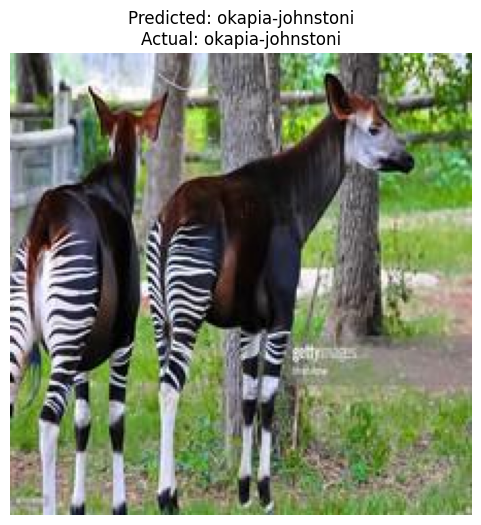

In [20]:
# Cell 20 - Test Prediction Using Test Dataset

import random
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

# Create prediction transform
predict_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Original ImageFolder dataset
original_test_dataset = test_dataset.dataset

# Pick a random image from our test subset
random_index = random.randrange(len(test_dataset))

# Convert subset index to original dataset index
original_index = test_dataset.indices[random_index]

# Get image path and true label
image_path, true_label = original_test_dataset.samples[original_index]

# Open image
image = Image.open(image_path).convert("RGB")

# Transform image
image_tensor = predict_transform(image)
image_tensor = image_tensor.unsqueeze(0).to(device)

# Predict
model.eval()

with torch.no_grad():
    output = model(image_tensor)
    probabilities = torch.softmax(output, dim=1)

# Get prediction
confidence, prediction = probabilities.max(1)

predicted_class = base_dataset.classes[prediction.item()]
actual_class = base_dataset.classes[true_label]

print("=" * 60)
print("🐾 ANIMAL IMAGE PREDICTION")
print("=" * 60)

print("Actual animal:   ", actual_class)
print("Predicted animal:", predicted_class)
print(f"Confidence:       {confidence.item() * 100:.2f}%")

print("=" * 60)

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Predicted: {predicted_class}\n"
    f"Actual: {actual_class}"
)
plt.show()

In [ ]:
# Cell 20 - Fast Animal Prediction

from google.colab import files
from PIL import Image

uploaded = files.upload()

image_path = next(iter(uploaded))
image = Image.open(image_path).convert("RGB")

# Prepare image
image_tensor = predict_transform(image)
image_tensor = image_tensor.unsqueeze(0).to(device)

# Predict
model.eval()

with torch.no_grad():
    output = model(image_tensor)
    probabilities = torch.softmax(output, dim=1)

# Best prediction
confidence, prediction = probabilities.max(1)

class_name = base_dataset.classes[prediction.item()]

print("=" * 50)
print("🐾 PREDICTION")
print("=" * 50)
print("Animal:", class_name)
print(f"Confidence: {confidence.item() * 100:.2f}%")
print("=" * 50)